# 05 — Computing 2-D radiative quantities from a MAJA output

This notebook shows how to derive spatially-varying radiative quantities from a
real Sentinel-2 L2A product processed by the **MAJA** atmospheric processor.

The key difference from notebook 03 is that all atmospheric and geometric
parameters ($AOT$, $h$, $h_{ref}$, SZA, VZA, …) come directly from the
product metadata rather than being set manually.  The convenience function
`config_from_scene` reads these variables from the loaded `ImageDict` and
assembles the `AtmoConfig` / `GeoConfig` / `SpectralConfig` bundle automatically.

**Workflow**

```
gaussian_image_dict()   # synthetic surface (spatial support)
       ↓
  MajaLoader            # injects aot, h, rh, href, sza, vza, saa, vaa
       ↓
config_from_scene()     # builds AtmoConfig / GeoConfig / SpectralConfig
       ↓
 RadiativePipeline      # Smart-G Monte-Carlo (GPU)
       ↓
 2-D maps of tdir_down, tdir_up, tdif_down, tdif_up, rho_atm, sph_alb
```

**Requires:** a configured `SMARTG_DIR_AUXDATA` environment variable, a GPU, and
access to a MAJA L2A product folder and the corresponding DEM.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt

from adjeff.api import config_from_scene
from adjeff.core import S2Band, gaussian_image_dict
from adjeff.modules.loaders import MajaLoader
from adjeff.modules.samplers import RadiativePipeline
from adjeff.utils import CacheStore

# Verify Smart-G is configured
assert "SMARTG_DIR_AUXDATA" in os.environ, (
    "Set SMARTG_DIR_AUXDATA to the Smart-G auxiliary data directory."
)

## 5.1 — Load the MAJA product

We first create a synthetic Gaussian surface (`gaussian_image_dict`) that
defines the **spatial support** of the scene (resolution, size, bands).
`MajaLoader` then injects the atmospheric and geometric parameters extracted
from the product folder into each band dataset.

Adjust `PRODUCT_PATH` and `MNT_PATH` to point to your local MAJA product and DEM.

In [2]:
PRODUCT_PATH = Path(
    "/home/kwalcarius/dev/current/adjeff/scripts/"
    "SENTINEL2B_20180616-102816-151_L2A_T32TMR_C_V1-0/"
)
MNT_PATH = Path("/home/kwalcarius/dev/current/adjeff/scripts/DTM/")

BANDS = [S2Band.B02]
BAND = S2Band.B02

cache = CacheStore("/tmp/adjeff-maja-cache")

# Synthetic surface — defines resolution (120 m) and spatial extent (915×915)
scene = gaussian_image_dict(sigma=15.0, res_km=0.120, bands=BANDS, n=915)

# Inject atmospheric/geometric parameters from the MAJA product
scene = MajaLoader(
    product_path=PRODUCT_PATH,
    mnt_path=MNT_PATH,
).forward(scene=scene)

print("Variables available for", BAND, ":")
print(list(scene[BAND].data_vars))

2026-04-14 17:02:22 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-14 17:02:22 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=915 rho_max=1.0 rho_min=0.0 sigma=15.0 var=rho_s
2026-04-14 17:02:22 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=c4cba2bb module=MajaLoader
2026-04-14 17:02:22 [info     ] Relative humidity not found, default to 50%. path=SENTINEL2B_20180616-102816-151_L2A_T32TMR_C_V1-0
(5490, 5490)
6
6
<xarray.Dataset> Size: 17MB
Dimensions:  (x: 915, y: 915, rh: 1, href: 1, sza: 1, vza: 1, saa: 1, vaa: 1)
Coordinates:
  * x        (x) float64 7kB -54.84 -54.72 -54.6 -54.48 ... 54.6 54.72 54.84
  * y        (y) float64 7kB -54.84 -54.72 -54.6 -54.48 ... 54.6 54.72 54.84
  * rh       (rh) float64 8B 50.0
  * href     (href) float64 8B 2.0
  * sza      (sza) float64 8B 25.2
  * vza      (vza) float64 8B 5.1
  * saa      (saa) float64 8B 146.9
  * vaa      (vaa) float64 8B 105.7
Data variables:
 

## 5.2 — Inspect the loaded parameters

`aot` and `h` are 2-D maps with dimensions `(x, y)`, co-registered with the
surface reflectance grid.  Scalar quantities (`rh`, `sza`, `vza`, …) are stored
as 1-D DataArrays with a single value (one measurement per acquisition).

Scalar parameters:
  rh     = 50.000
  href   = 2.000
  sza    = 25.200
  saa    = 146.880
  vza    = 5.100
  vaa    = 105.660

Spatial parameters:
  aot   dims=['y', 'x']  min=0.0014  max=0.7450
  h     dims=['y', 'x']  min=0.0507  max=4.5366


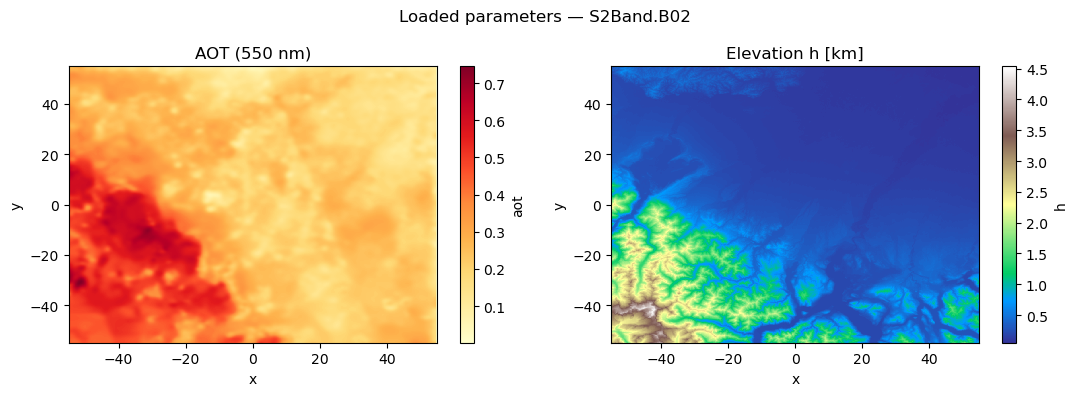

In [3]:
ds = scene[BAND]

print("Scalar parameters:")
for var in ["rh", "href", "sza", "saa", "vza", "vaa"]:
    print(f"  {var:6s} = {float(ds[var].squeeze()):.3f}")

print()
print("Spatial parameters:")
for var in ["aot", "h"]:
    da = ds[var]
    print(
        f"  {var:4s}  dims={list(da.dims)}  "
        f"min={float(da.min()):.4f}  max={float(da.max()):.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ds["aot"].plot(ax=axes[0], cmap="YlOrRd")
axes[0].set_title("AOT (550 nm)")
ds["h"].plot(ax=axes[1], cmap="terrain")
axes[1].set_title("Elevation h [km]")
plt.suptitle(f"Loaded parameters — {BAND}", fontsize=12)
plt.tight_layout()
plt.show()

## 5.3 — Build the configuration with `config_from_scene`

`config_from_scene` reads all required variables directly from the scene and
assembles the three config objects.  The `n_bins` argument **digitizes** the
continuous `aot` and `h` maps into a small set of discrete values: instead of
one Smart-G call per pixel, only `n_bins²` unique atmospheric states are
simulated, which is far more efficient.

The returned dict can be unpacked directly into `RadiativePipeline`.

In [4]:
N_BINS = 10

config = config_from_scene(scene, band=BAND, n_bins=N_BINS)

print("AtmoConfig:")
print(" ", config["atmo_config"])
print("GeoConfig:")
print(" ", config["geo_config"])
print("SpectralConfig:")
print(" ", config["spectral_config"])

AtmoConfig:
  aot=<xarray.DataArray (y: 915, x: 915)> Size: 7MB
array([[0.41450617, 0.41450617, 0.41450617, ..., 0.1666358 , 0.1666358 ,
        0.00138889],
       [0.41450617, 0.41450617, 0.41450617, ..., 0.1666358 , 0.1666358 ,
        0.00138889],
       [0.41450617, 0.41450617, 0.41450617, ..., 0.1666358 , 0.1666358 ,
        0.00138889],
       ...,
       [0.24925926, 0.24925926, 0.24925926, ..., 0.08401235, 0.08401235,
        0.00138889],
       [0.24925926, 0.24925926, 0.24925926, ..., 0.08401235, 0.08401235,
        0.00138889],
       [0.00138889, 0.00138889, 0.00138889, ..., 0.00138889, 0.00138889,
        0.00138889]], shape=(915, 915))
Coordinates:
  * y        (y) float64 7kB -54.84 -54.72 -54.6 -54.48 ... 54.6 54.72 54.84
  * x        (x) float64 7kB -54.84 -54.72 -54.6 -54.48 ... 54.6 54.72 54.84
Attributes:
    _adjeff_provenance:  {'module': 'MajaLoader', 'key': 'c4cba2bbc7df95322f9... h=<xarray.DataArray (y: 915, x: 915)> Size: 7MB
array([[3.04131481, 3.04131481, 3

## 5.4 — Run the radiative pipeline

We pass `deduplicate_dims=["x", "y"]` so that identical atmospheric states
that appear at multiple spatial locations are collapsed into a single Smart-G
call.  Combined with the digitization above, this makes the computation
tractable on a full 915×915 scene.

Results are cached to disk so that re-running the cell skips the GPU
computation.

In [5]:
pipeline = RadiativePipeline(
    **config,
    remove_rayleigh=False,
    n_ph_rho_atm=int(1e6),
    n_ph_sph_alb=int(1e6),
    n_ph_tdif_down=int(1e6),
    n_ph_tdif_up=int(1e6),
    deduplicate_dims=["x", "y"],
    cache=cache,
)

scene = pipeline(scene)

print("Computed variables for", BAND, ":")
for var in ["tdir_down", "tdir_up", "tdif_down", "tdif_up", "rho_atm", "sph_alb"]:
    da = scene[BAND][var].compute()
    print(f"  {var:12s}  dims={list(da.dims)}")

2026-04-14 17:02:25 [debug    ] cache miss                     band=S2Band.B02(490.0nm) key=4059c85e
2026-04-14 17:02:25 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=4059c85e module=SmartgSampler_Tdir_down
2026-04-14 17:02:25 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['y', 'x'], 'h': ['y', 'x'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'sza']
2026-04-14 17:02:26 [debug    ] Deduplicated                   demoted_to_scalar=[] eff_dims=['x', 'y'] n_original=837225 n_unique=60 reduction_factor=13953.75
2026-04-14 17:02:26 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['index'], 'h': ['index'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza']} deduplicated=True flat_dims=[]
2026-04-14 17:02:26 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 17:02:26 [info     ] Computing tdir_d

Box(children=(FloatProgress(value=0.0, max=1000.0), Label(value='')), layout=Layout(align_items='center', disp…

There is no current context to clear.
2026-04-14 17:02:32 [info     ] tdir_down successfully calculated.
2026-04-14 17:02:32 [debug    ] Reconstructed original dimensions. dims=['wl', 'x', 'y', 'rh', 'href', 'sza'] shape=(1, 915, 915, 1, 1, 1)
2026-04-14 17:02:32 [info     ] Computed tdir_down.            dims=('wl', 'x', 'y', 'rh', 'href', 'sza')
2026-04-14 17:02:32 [info     ] Computation finished           key=4059c85e module=SmartgSampler_Tdir_down vars=['tdir_down']
2026-04-14 17:02:32 [debug    ] Scene was saved to cache.      band=S2Band.B02(490.0nm) key=4059c85e path=/tmp/adjeff-maja-cache/4059c85ecdeceaf612c9dd692a42c75c/S2Band.B02.zarr vars=['tdir_down']


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


2026-04-14 17:02:34 [debug    ] cache miss                     band=S2Band.B02(490.0nm) key=2d871373
2026-04-14 17:02:34 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=2d871373 module=SmartgSampler_Tdir_up
2026-04-14 17:02:34 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['y', 'x'], 'h': ['y', 'x'], 'rh': ['rh'], 'href': ['href'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza']
2026-04-14 17:02:34 [debug    ] Deduplicated                   demoted_to_scalar=[] eff_dims=['x', 'y'] n_original=837225 n_unique=60 reduction_factor=13953.75
2026-04-14 17:02:34 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['index'], 'h': ['index'], 'rh': ['rh'], 'href': ['href'], 'vza': ['vza']} deduplicated=True flat_dims=[]
2026-04-14 17:02:34 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 17:02:34 [debug    ] Atmosphere LUT gen

...

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


2026-04-14 17:03:18 [debug    ] cache miss                     band=S2Band.B02(490.0nm) key=12bf8943
2026-04-14 17:03:18 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=12bf8943 module=SmartgSampler_Rho_atm
2026-04-14 17:03:18 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['y', 'x'], 'h': ['y', 'x'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['band_type', 'species', 'sat_height'] scalars=[] vectors=['wl', 'aot', 'rh', 'h', 'href', 'vza', 'sza']
2026-04-14 17:03:19 [debug    ] Deduplicated                   demoted_to_scalar=[] eff_dims=['x', 'y'] n_original=837225 n_unique=60 reduction_factor=13953.75
2026-04-14 17:03:19 [debug    ] Initialization finshed.        arrays={'wl': ['wl'], 'aot': ['index'], 'h': ['index'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} deduplicated=True flat_dims=[]
2026-04-14 17:03:19 [debug    ] Sweep step                     coords={} step=1/1
2026-04-14 

Box(children=(FloatProgress(value=0.0, max=60000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-14 17:03:27 [info     ] rho_atm successfully calculated.
2026-04-14 17:03:27 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'x', 'y', 'rh', 'href'] shape=(1, 1, 1, 915, 915, 1, 1)
2026-04-14 17:03:27 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'x', 'y', 'rh', 'href')
2026-04-14 17:03:27 [info     ] Computation finished           key=12bf8943 module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-14 17:03:27 [debug    ] Scene was saved to cache.      band=S2Band.B02(490.0nm) key=12bf8943 path=/tmp/adjeff-maja-cache/12bf894310707ca51b630037f5ddc3b2/S2Band.B02.zarr vars=['rho_atm']
Computed variables for S2Band.B02 :
  tdir_down     dims=['x', 'y', 'rh', 'href', 'sza']
  tdir_up       dims=['x', 'y', 'rh', 'href', 'vza']
  tdif_down     dims=['sza', 'x', 'y', 'rh', 'href']
  tdif_up       dims=['vza', 'x', 'y', 'rh', 'href']
  rho_atm       dims=['vza', 'sza', 'x', 'y', 'rh', 'href']
  sph_alb 

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## 5.5 — Visualise the 2-D radiative maps

Each radiative quantity inherits the spatial structure of the digitized AOT
and elevation maps.  The spatial patterns in `sph_alb`, `tdif_up`, and
`tdif_down` reflect the aerosol and terrain variability across the scene.

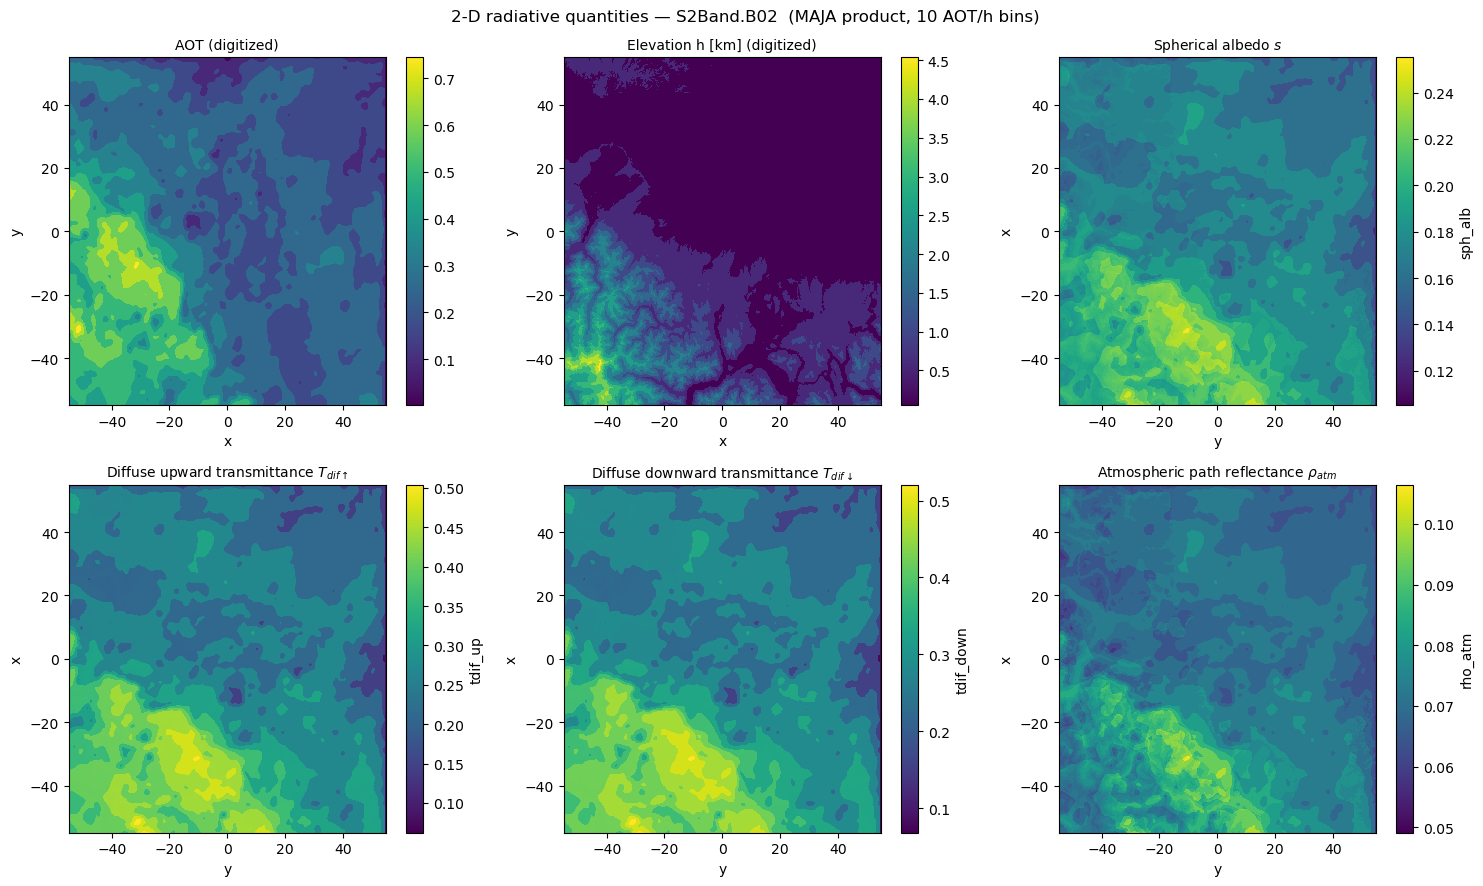

In [6]:
VARS = ["aot", "h", "sph_alb", "tdif_up", "tdif_down", "rho_atm"]
TITLES = [
    "AOT (digitized)",
    "Elevation h [km] (digitized)",
    "Spherical albedo $s$",
    "Diffuse upward transmittance $T_{dif\\uparrow}$",
    "Diffuse downward transmittance $T_{dif\\downarrow}$",
    "Atmospheric path reflectance $\\rho_{atm}$",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, var, title in zip(axes.flat, VARS, TITLES):
    da = scene[BAND][var]
    if var in ("aot", "h"):
        da = da.adjeff.digitize(n_bins=N_BINS)
    da.compute().plot(ax=ax)
    ax.set_title(title, fontsize=10)

fig.suptitle(
    f"2-D radiative quantities — {BAND}  (MAJA product, {N_BINS} AOT/h bins)",
    fontsize=12,
)
plt.tight_layout()
plt.show()